# Definindo Parâmetros

## Modelo: Regressão Logistica

O objetivo desse notebook é analisar o funcionamento do modelo de classificação Regressão Logistitca para definir o gênero de uma música com base nas suas audio features

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib
import os
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

## Leitura dos Dados

In [9]:
caminho_arquivo = '../data/spotify_songs.csv'

df = pd.read_csv(caminho_arquivo)

features = ['danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'explicit', 'tempo']

## Limpeza do Dataset: removendo duplicatas

In [10]:
print(f"Quantidade de músicas antes da limpeza: {df.shape[0]}")

df_limpo = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')

print(f"Quantidade de músicas após a limpeza: {df_limpo.shape[0]}")

df = df_limpo.copy()

Quantidade de músicas antes da limpeza: 114000
Quantidade de músicas após a limpeza: 81344


## Normalizando a matriz das features

In [11]:
# Selecionamos as colunas das audio features que importam
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Aplicando a clusterização: K-Means

Resolvemos aplicar o modelo não supervisionado K-means para organizar nossas músicas em grupos com base nas suas audio features, uma vez que se considerássemos apenas a coluna `track_genre` para fazermos nossa classificação o modelo teria que lidar com 114 classes e apresentaria baixos valores de f1-score e acurácia.

In [12]:
print("Treinando o K-Means...")
kmeans = KMeans(n_clusters=15, random_state=42, n_init='auto')
df['macrogenero'] = kmeans.fit_predict(X_scaled)

print("Clusterização concluída! Nova coluna 'macrogenero' criada.")

Treinando o K-Means...
Clusterização concluída! Nova coluna 'macrogenero' criada.


## Regressão Logistica

In [13]:
# Separando em Treino e Teste (80% para treinar, 20% para testar)
X_train, X_test, y_train, y_test = train_test_split(
    X, df['macrogenero'], test_size=0.2, random_state=42
)

In [39]:
# Instanciando e Treinando a Regressão Logistica
print("Iniciando o treinamento da Regressão Logistica")

# param_grid = {
#     'penalty': ['l1', 'l2'],
#     'C': [0.01, 0.1, 1.0, 10.0],
#     'solver': ['saga'], 
#     'class_weight': ['balanced', None]
# }

param_grid = {
    'penalty': ['l1'],
    'C': [1.0],
    'solver': ['saga'], 
    'class_weight': ['balanced']
}

lr_base = LogisticRegression(max_iter=5000)

buscador = GridSearchCV(
    estimator=lr_base, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=2 
)

print("Iniciando a busca pelos melhores hiperparâmetros...")
buscador.fit(X_train, y_train)

print(f"A melhor combinação encontrada foi: {buscador.best_params_}")
print(f"O melhor F1-Score obtido nos testes foi: {buscador.best_score_:.2f}")

Iniciando o treinamento da Regressão Logistica
Iniciando a busca pelos melhores hiperparâmetros...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
A melhor combinação encontrada foi: {'C': 1.0, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
O melhor F1-Score obtido nos testes foi: 0.94


In [15]:
melhor_modelo_lr = buscador.best_estimator_
y_pred = melhor_modelo_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93      2557
           1       0.94      0.93      0.94      1220
           2       0.94      0.96      0.95      1097
           3       0.80      0.91      0.85       528
           4       0.91      0.98      0.94       201
           5       0.98      0.97      0.97       815
           6       0.93      0.96      0.95       959
           7       0.94      0.90      0.92      1992
           8       0.97      0.99      0.98       443
           9       0.99      0.98      0.99       716
          10       0.90      0.94      0.92      1145
          11       0.90      0.98      0.94       696
          12       0.93      0.96      0.95       669
          13       0.92      0.92      0.92      1560
          14       0.94      0.94      0.94      1671

    accuracy                           0.94     16269
   macro avg       0.93      0.95      0.94     16269
weighted avg       0.94   

In [40]:
# Criamos um dicionário vazio para guardar nossos modelos E nossos scalers correspondentes
especialistas = {}

todas_as_vibes = df['macrogenero'].unique()

print("Treinando os Especialistas Lineares (Regressão Logística com Filtro de Ruído)...\n")

# Variável de controle: Um gênero precisa ter pelo menos 15 músicas 
# dentro de um cluster para ser levado a sério pelo especialista
MIN_MUSICAS_POR_GENERO = 15

for vibe in todas_as_vibes:
    df_vibe = df[df['macrogenero'] == vibe]
    
    # Realizamos o filtro dentro do cluster para remover ruídos e gêneros raros
    contagem = df_vibe['track_genre'].value_counts()
    generos_fortes = contagem[contagem >= MIN_MUSICAS_POR_GENERO].index
    df_vibe_limpo = df_vibe[df_vibe['track_genre'].isin(generos_fortes)]

    # Caso o cluster tenha apenas 1 gênero forte após a limpeza
    if len(df_vibe_limpo['track_genre'].unique()) <= 1:
        genero_unico = contagem.index[0] 
        # Salvamos uma estrutura padronizada indicando que este cluster é de gênero fixo
        especialistas[vibe] = {
            "tipo": "fixo",
            "modelo": genero_unico,
            "scaler": None
        }
        print(f"[{vibe}] - Ruído muito alto. Ficará fixo no gênero principal: '{genero_unico}'.")
        continue

    # Definimos X e y usando o dataframe limpo
    X_especialista = df_vibe_limpo[features]
    y_especialista = df_vibe_limpo['track_genre']
    
    scaler_especialista = StandardScaler()
    X_especialista_scaled = scaler_especialista.fit_transform(X_especialista)
    
    modelo_especialista = LogisticRegression(
        **buscador.best_params_,  # Passa automaticamente o melhor C, penalty, class_weight, etc.
        max_iter=5000,            # Mantém os parâmetros estruturais fixos
        random_state=42,
        n_jobs=-1
    )
    
    # Treina o modelo com os dados escalonados
    modelo_especialista.fit(X_especialista_scaled, y_especialista)
    
    especialistas[vibe] = {
        "tipo": "modelo",
        "modelo": modelo_especialista,
        "scaler": scaler_especialista
    }
    
    print(f"[{vibe}] - Especialista treinado! Gêneros reduzidos para: {len(y_especialista.unique())} (Eram {len(contagem)}).")

print("\nTodos os especialistas em Regressão Logística estão prontos e calibrados!")

Treinando os Especialistas Lineares (Regressão Logística com Filtro de Ruído)...

[0] - Especialista treinado! Gêneros reduzidos para: 98 (Eram 110).


c:\Bibliotecas\LocalDocuments\02_Projetos\trabalho-iml-spotify\backend\venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[1] - Especialista treinado! Gêneros reduzidos para: 66 (Eram 96).
[10] - Especialista treinado! Gêneros reduzidos para: 75 (Eram 109).
[13] - Especialista treinado! Gêneros reduzidos para: 85 (Eram 107).
[7] - Especialista treinado! Gêneros reduzidos para: 102 (Eram 113).
[14] - Especialista treinado! Gêneros reduzidos para: 88 (Eram 112).


c:\Bibliotecas\LocalDocuments\02_Projetos\trabalho-iml-spotify\backend\venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[6] - Especialista treinado! Gêneros reduzidos para: 79 (Eram 113).


...

[9] - Especialista treinado! Gêneros reduzidos para: 46 (Eram 95).


c:\Bibliotecas\LocalDocuments\02_Projetos\trabalho-iml-spotify\backend\venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[12] - Especialista treinado! Gêneros reduzidos para: 33 (Eram 78).
[5] - Especialista treinado! Gêneros reduzidos para: 19 (Eram 40).
[2] - Especialista treinado! Gêneros reduzidos para: 39 (Eram 94).


c:\Bibliotecas\LocalDocuments\02_Projetos\trabalho-iml-spotify\backend\venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[3] - Especialista treinado! Gêneros reduzidos para: 53 (Eram 102).
[8] - Especialista treinado! Gêneros reduzidos para: 37 (Eram 89).
[11] - Especialista treinado! Gêneros reduzidos para: 36 (Eram 78).
[4] - Ruído muito alto. Ficará fixo no gênero principal: 'comedy'.

Todos os especialistas em Regressão Logística estão prontos e calibrados!


In [41]:
def classificar_musica_hierarquicamente(audio_features_nova_musica):
    """
    Recebe um DataFrame de 1 linha contendo as features numéricas da música.
    Exemplo: audio_features_nova_musica = X_test.iloc[[0]]
    """
    # 1. Fase do Roteador (Macro-gênero)
    macrogenero_predito = melhor_modelo_lr.predict(audio_features_nova_musica)[0]
    
    # 2. Resgata o pacote do especialista correspondente à vibe
    info_especialista = especialistas[macrogenero_predito]
    
    # 3. Verifica a natureza do especialista
    if info_especialista["tipo"] == "fixo":
        # Caiu na regra do filtro de ruído (gênero dominante único)
        genero_predito = info_especialista["modelo"]
    else:
        # Caiu em um modelo linear treinado
        modelo_local = info_especialista["modelo"]
        scaler_local = info_especialista["scaler"]
    
        features_escalonadas = scaler_local.transform(audio_features_nova_musica)
        
        # Pede para o mini-modelo decidir qual é o gênero final com os dados ajustados
        genero_predito = modelo_local.predict(features_escalonadas)[0]
        
    return macrogenero_predito, genero_predito

## Testando a nossa cascata com uma música aleatória

In [96]:
# Sorteia 1 índice (linha) aleatório APENAS DA BASE DE TESTE (Dados Inéditos)
indice_sorteado = X_test.sample(n=1).index[0]

# Extrai as informações usando esse índice
musica_sorteada_features = X_test.loc[[indice_sorteado]]
vibe_real = y_test.loc[indice_sorteado]
genero_real = df.loc[indice_sorteado, 'track_genre']
nome_musica = df.loc[indice_sorteado, 'track_name']
artista_musica = df.loc[indice_sorteado, 'artists']

# Aciona a pipeline adaptada (Roteador -> Scaler Local -> Regressão Logística)
vibe_predita, genero_predito = classificar_musica_hierarquicamente(musica_sorteada_features)

# --- Impressão dos Resultados ---
print("="*60)
print(f"🎵 MÚSICA SORTEADA: {nome_musica} - {artista_musica}")
print("="*60)
print("GABARITO REAL (O QUE ELA REALMENTE É):")
print(f"  - Macro-gênero Original: '{vibe_real}'")
print(f"  - Gênero Original:       '{genero_real}'")
print("-" * 60)
print("PREVISÃO DO NOSSO PIPELINE DE MACHINE LEARNING:")
print(f"  - Fase 1 (Roteador) previu a Vibe:       -> '{vibe_predita}'")
print(f"  - Fase 2 (Especialista) previu o Gênero: -> '{genero_predito}'")
print("="*60)

# Verificação de acerto visual
if genero_real == genero_predito:
    print("✅ RESULTADO: O modelo ACERTOU NA MOSCA!")
elif vibe_real == vibe_predita:
    print("⚠️ RESULTADO: Acertou o Macro-gênero, mas confundiu o subgênero interno.")
else:
    print("❌ RESULTADO: O modelo errou a previsão completamente.")

🎵 MÚSICA SORTEADA: Sugar - Kittie
GABARITO REAL (O QUE ELA REALMENTE É):
  - Macro-gênero Original: '14'
  - Gênero Original:       'industrial'
------------------------------------------------------------
PREVISÃO DO NOSSO PIPELINE DE MACHINE LEARNING:
  - Fase 1 (Roteador) previu a Vibe:       -> '14'
  - Fase 2 (Especialista) previu o Gênero: -> 'metalcore'
⚠️ RESULTADO: Acertou o Macro-gênero, mas confundiu o subgênero interno.


## Visualizando matriz de confusão e gráfico de importância de features

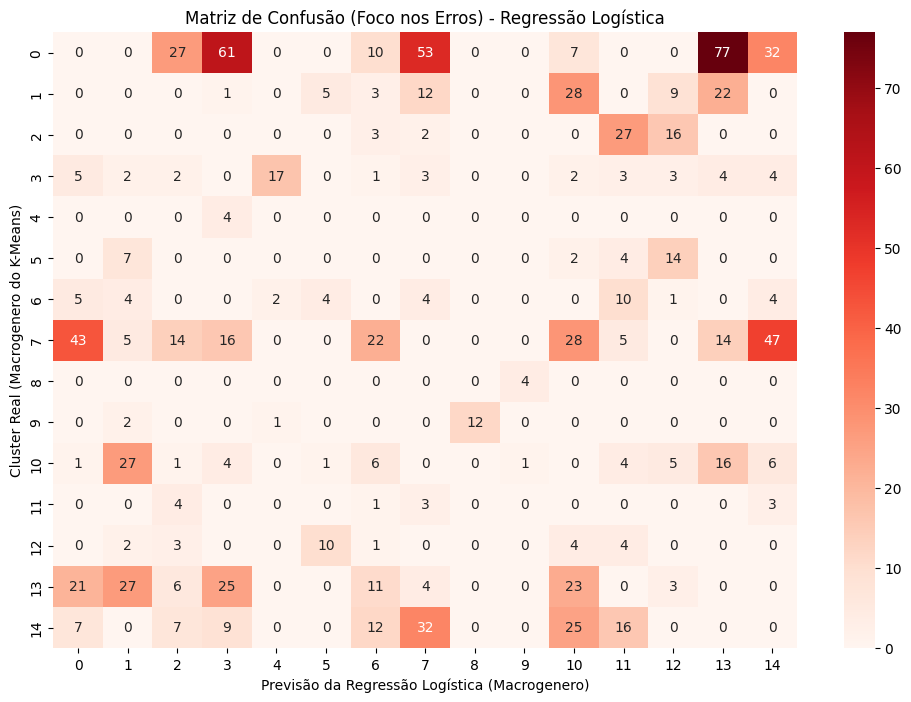

In [97]:
y_pred_lr = melhor_modelo_lr.predict(X_test)

conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

# Zerando a diagonal principal (acertos) para focar a visualização nos erros
np.fill_diagonal(conf_matrix_lr, 0)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Reds')

plt.xlabel('Previsão da Regressão Logística (Macrogenero)')
plt.ylabel('Cluster Real (Macrogenero do K-Means)')
plt.title('Matriz de Confusão (Foco nos Erros) - Regressão Logística')
plt.show()

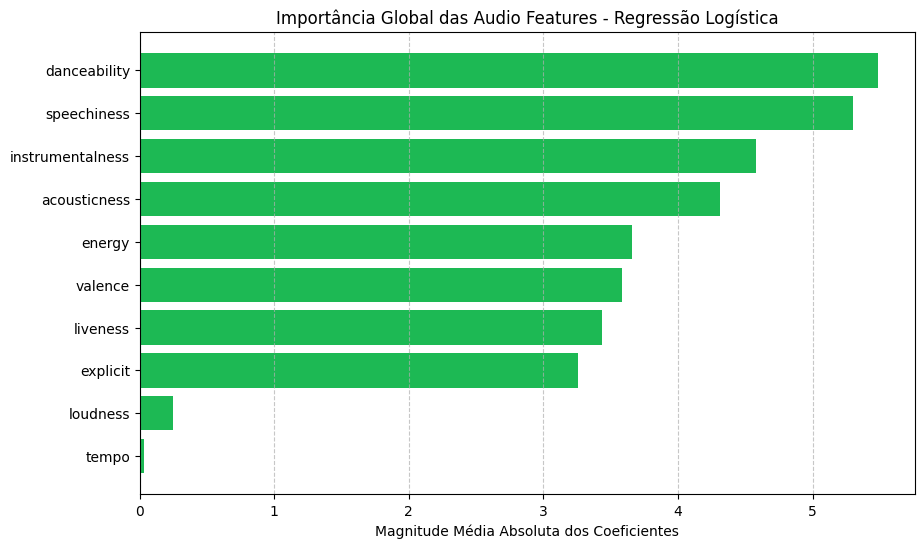

In [44]:
importancias_globais = np.mean(np.abs(melhor_modelo_lr.coef_), axis=0)

# Criamos um DataFrame para organizar os dados do maior para o menor
df_importancias = pd.DataFrame({
    'Feature': features, # Supondo que 'features' seja a sua lista ['energy', 'danceability', ...]
    'Importância': importancias_globais
}).sort_values(by='Importância', ascending=True)

# Pegamos apenas as 10 mais importantes para o gráfico ficar limpo
df_top_10 = df_importancias.tail(10)

plt.figure(figsize=(10, 6))
plt.barh(df_top_10['Feature'], df_top_10['Importância'], color='#1DB954') # Usando o verde do Spotify!

plt.xlabel('Magnitude Média Absoluta dos Coeficientes')
plt.title('Importância Global das Audio Features - Regressão Logística')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Salvando nosso modelo treinado

In [98]:
salvar = True

if salvar:    
    # 1. Garantir que a pasta existe na raiz do backend
    os.makedirs("../backend/models/lr", exist_ok=True)

    # 2. Salvar o Modelo Roteador (A Fase 1)
    # Alterei o nome do arquivo para algo mais genérico, já que pode ser um K-Means ou LightGBM
    caminho_roteador = "../backend/models/lr/lr_macrogenero.pkl"
    caminho_scaler_global = "../backend/models/lr/scaler_global.pkl"

    joblib.dump(melhor_modelo_lr, caminho_roteador)
    joblib.dump(scaler, caminho_scaler_global) 

    print(f"Roteador salvo em: {caminho_roteador}")
    print(f"Scaler Global salvo em: {caminho_scaler_global}\n")

    # 3. Salvar os Pacotes Especialistas (A Fase 2: Modelo + Scaler)
    print("Salvando os Especialistas (Regressão Logística)...")
    for vibe, info_especialista in especialistas.items():
        # Boa prática: limpar o nome da vibe para evitar erros de formatação no Windows/Linux
        nome_arquivo_vibe = str(vibe).replace(" ", "_").replace("/", "_")
        caminho_especialista = f"../backend/models/lr/lr_especialista_{nome_arquivo_vibe}.pkl"
        
        # O joblib salva o dicionário inteiro perfeitamente!
        joblib.dump(info_especialista, caminho_especialista)
        print(f" -> Salvo: {caminho_especialista}")

    print(f"\nTodos os {len(especialistas)} pacotes de especialistas foram salvos com sucesso e estão prontos para o FastAPI!")

Roteador salvo em: ../backend/models/lr/lr_macrogenero.pkl
Scaler Global salvo em: ../backend/models/lr/scaler_global.pkl

Salvando os Especialistas (Regressão Logística)...
 -> Salvo: ../backend/models/lr/lr_especialista_0.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_1.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_10.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_13.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_7.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_14.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_6.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_9.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_12.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_5.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_2.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_3.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_8.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_11.pkl
 -> Salvo: ../backend/models/lr/lr_especialista_4.pkl

Todos os 1